    Análise de Emissões de Gases no Brasil

  1. Objetivo do Projeto

  Este projeto tem como objetivo analisar dados de emissões de gases de efeito estufa no Brasil utilizando Python e Pandas.
A análise busca responder perguntas como:

    1.1. Quais setores mais emitem CO2?
    1.2. Como as emissões evoluíram ao longo do tempo?
    1.3. Quais estados possuem maiores emissões?
    1.4. Quais padrões podem ser observados nos dados?

2. Importação das Bibliotecas

In [167]:
# Pandas será utilizado para manipulação de dados.
# Matplotlib será utilizado para visualização gráfica.

import pandas as pd
import matplotlib.pyplot as plt

3. Carregamento dos Dados

In [241]:
# O dataset é carregado a partir da pasta data, tornando o projeto portátil e executável em qualquer máquina.
caminho = 'data/SEEG10.xlsx'
emissoes_gases = pd.read_excel(caminho, sheet_name='GEE Estados')

/Users/macbookm1/.pyenv/versions/3.13.0/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


4. Visualização Inicial dos Dados

In [168]:
# A função head() permite visualizar as primeiras linhas do dataset e entender sua estrutura.
emissoes_gases.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,Emissão,COVNM (t),SP,OUTRA_IND,...,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600,897.600
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,N2O (t),SP,OUTRA_IND,...,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000,130.000
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO (t),SP,OUTRA_IND,...,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576,1380.576
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,NOx (t),SP,OUTRA_IND,...,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430,431.430
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,SP,OUTRA_IND,...,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000,40300.000


In [169]:
# A função info() mostra:
# • quantidade de linhas;
# • quantidade de colunas;
# • tipos de dados;
# • valores nulos.
# Essa etapa é importante para identificar problemas de qualidade nos dados.

emissoes_gases.info()

<class 'pandas.DataFrame'>
RangeIndex: 103312 entries, 0 to 103311
Data columns (total 63 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Nível 1 - Setor             103312 non-null  str    
 1   Nível 2                     103312 non-null  str    
 2   Nível 3                     103253 non-null  str    
 3   Nível 4                     90920 non-null   str    
 4   Nível 5                     100788 non-null  str    
 5   Nível 6                     97691 non-null   str    
 6   Emissão / Remoção / Bunker  103312 non-null  str    
 7   Gás                         103312 non-null  str    
 8   Estado                      97374 non-null   str    
 9   Atividade Econômica         102076 non-null  str    
 10  Produto                     37413 non-null   str    
 11  1970                        103312 non-null  float64
 12  1971                        103312 non-null  float64
 13  1972                     

6. Análise dos Tipos de Emissão

In [172]:
# A função unique() identifica todos os valores distintos presentes na coluna.
emissoes_gases['Emissão / Remoção / Bunker'].unique()

<StringArray>
['Emissão', 'Emissão NCI', 'Remoção NCI', 'Bunker', 'Remoção']
Length: 5, dtype: str

7. Filtragem de Remoções

In [174]:
# utilizamos isin() para selecionar apenas registros relacionados a remoções de gases.
remocoes = emissoes_gases[emissoes_gases['Emissão / Remoção / Bunker'].isin(['Remoção NCI', 'Remoção'])]

8. Análise Temporal das Remoções

In [176]:
# Essa seleção permite observar os dados de emissão ao longo dos anos.
remocoes.loc[:, 1970:2021]

,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
23520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.434540e+07,-1.499358e+07,-1.543196e+07,-1.567070e+07,-1.630063e+07,-1.702215e+07,-1.740074e+07,-1.771914e+07,-1.767632e+07,-1.838895e+07
23521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-5.382949e+06,-5.524659e+06,-5.632429e+06,-5.765030e+06,-5.867354e+06,-5.942076e+06,-6.022000e+06,-6.002147e+06,-6.035591e+06,-6.459079e+06
23522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-3.450455e+06,-3.540294e+06,-3.545724e+06,-3.924546e+06,-4.626541e+06,-4.874199e+06,-4.849173e+06,-4.959540e+06,-5.106806e+06,-5.809814e+06
23523,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.260166e+06,-1.261895e+06,-1.371664e+06,-1.501452e+06,-1.507705e+06,-1.509919e+06,-1.609826e+06,-1.616980e+06,-1.518397e+06,-1.926000e+06
23524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-3.429279e+07,-3.317185e+07,-3.281628e+07,-3.350720e+07,-3.557183e+07,-3.755308e+07,-4.134614e+07,-4.229403e+07,-4.275448e+07,-4.443440e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102751,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102752,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04
102753,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-7.513000e+04,-7.911900e+04,-8.695900e+04,-9.201400e+04,-9.149400e+04,-9.630200e+04,-9.202000e+04,-9.762300e+04,-1.015020e+05,-1.008910e+05
102754,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-9.523000e+03,-9.667000e+03,-1.000300e+04,-1.024200e+04,-1.027200e+04,-1.019100e+04,-1.046900e+04,-1.090400e+04,-1.104100e+04,-1.109500e+04


9. Valores Máximos das Remoções

In [179]:
# função max() identifica os maiores valores de remoção para cada ano.
remocoes.loc[:, 1970:2021].max()

1970    0.0
1971    0.0
1972    0.0
1973    0.0
1974    0.0
1975    0.0
1976    0.0
1977    0.0
1978    0.0
1979    0.0
1980    0.0
1981    0.0
1982    0.0
1983    0.0
1984    0.0
1985    0.0
1986    0.0
1987    0.0
1988    0.0
1989    0.0
1990    0.0
1991    0.0
1992    0.0
1993    0.0
1994    0.0
1995    0.0
1996    0.0
1997    0.0
1998    0.0
1999    0.0
2000    0.0
2001    0.0
2002    0.0
2003    0.0
2004    0.0
2005    0.0
2006    0.0
2007    0.0
2008    0.0
2009    0.0
2010    0.0
2011    0.0
2012    0.0
2013    0.0
2014    0.0
2015    0.0
2016    0.0
2017    0.0
2018    0.0
2019    0.0
2020    0.0
2021    0.0
dtype: float64

10. Identificação de Dados de Bunker

In [181]:
# Essa análise identifica quais estados possuem registros classificados como Bunker.
emissoes_gases.loc[emissoes_gases['Emissão / Remoção / Bunker'] == 'Bunker', 'Estado'].unique()

<StringArray>
[nan]
Length: 1, dtype: str

11. Filtragem Apenas de Emissões

In [186]:
# Nesta etapa removemos os registros de remoção e bunker para focar apenas nas emissões.
emissoes_gases = emissoes_gases[emissoes_gases['Emissão / Remoção / Bunker'] == 'Emissão'] 

12. Remoção de Colunas Desnecessárias

In [187]:
# Após a filtragem, a coluna deixa de ser necessária.
emissoes_gases = emissoes_gases.drop(columns = 'Emissão / Remoção / Bunker')

13. Identificação dos Setores

In [188]:
# Essa etapa identifica os setores econômicos presentes no dataset.
emissoes_gases['Nível 1 - Setor'].unique()

<StringArray>
[             'Processos Industriais',                       'Agropecuária',
                            'Energia',                          'Resíduos ',
 'Mudança de Uso da Terra e Floresta']
Length: 5, dtype: str

In [189]:
# Essa etapa identifica os estados presentes no dataset.
emissoes_gases['Estado'].unique()

<StringArray>
['SP', 'BA', 'RJ', 'MG', 'SE', 'PR',  nan, 'RO', 'AM', 'PA', 'TO', 'MA', 'PI',
 'CE', 'RN', 'PB', 'PE', 'AL', 'MT', 'MS', 'GO', 'DF', 'ES', 'SC', 'RS', 'AC',
 'AP', 'RR']
Length: 28, dtype: str

14. Emissões Totais por Setor

In [258]:
# O groupby() permite agrupar os dados por setor e calcular o total de emissões.
emissao_setores = emissoes_gases.groupby('Nível 1 - Setor')[2021].sum()

In [259]:
emissoes_gases[emissoes_gases['Estado'].isin(['PR', 'MS', 'SC'])]

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Emissão / Remoção / Bunker,Gás,Estado,Atividade Econômica,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
35,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,Emissão,CO2 (t),PR,OUTRA_IND,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
36,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,Emissão,CO2e (t) GWP-AR2,PR,OUTRA_IND,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
37,Processos Industriais,Indústria Química,Produção de Amônia,NaN,NaN,NaN,Emissão,CO2e (t) GTP-AR2,PR,OUTRA_IND,...,4.562042e+05,4.682616e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05,5.151689e+05
103,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,Emissão,CO2 (t),MS,CIM,...,3.712625e+05,3.417880e+05,3.162383e+05,3.063514e+05,2.644430e+05,2.293934e+05,2.221101e+05,2.522796e+05,2.997752e+05,3.267035e+05
110,Processos Industriais,Produtos Minerais,Produção de Cimento,NaN,NaN,NaN,Emissão,CO2 (t),PR,CIM,...,2.012596e+06,2.212002e+06,2.241143e+06,2.176752e+06,2.279061e+06,2.115372e+06,2.173266e+06,2.230656e+06,2.488650e+06,2.845457e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103237,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR2,MS,AGROPEC,...,3.793180e+05,4.325770e+05,3.801810e+05,3.131310e+05,3.778480e+05,3.353940e+05,3.520700e+05,3.780840e+05,7.574630e+05,8.695380e+05
103239,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR4,MS,AGROPEC,...,4.186050e+05,4.782330e+05,4.205630e+05,3.477570e+05,4.185090e+05,3.724170e+05,3.915000e+05,4.179760e+05,8.353770e+05,9.608320e+05
103241,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR5,MS,AGROPEC,...,4.369350e+05,5.000670e+05,4.400300e+05,3.652720e+05,4.384220e+05,3.911130e+05,4.117380e+05,4.370390e+05,8.713930e+05,1.004191e+06
103243,Mudança de Uso da Terra e Floresta,Resíduos Florestais,Pantanal,NaN,Desmatamento,NaN,Emissão,CO2e (t) GWP-AR6,MS,AGROPEC,...,4.395240e+05,5.029080e+05,4.424930e+05,3.671160e+05,4.407980e+05,3.931010e+05,4.137490e+05,4.395260e+05,8.766370e+05,1.009968e+06


15. Visualização Gráfica das Emissões por Setor

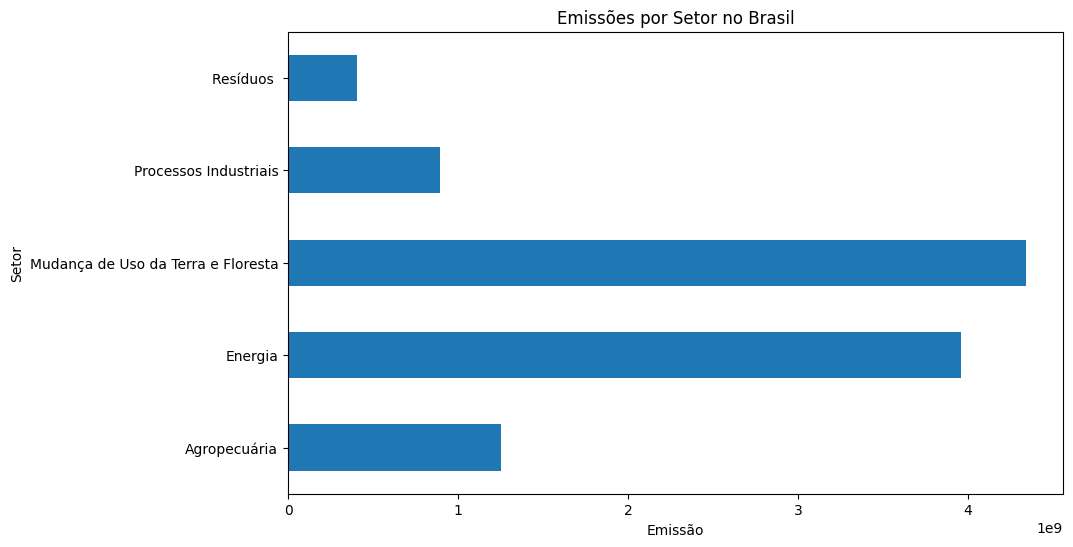

In [266]:
emissao_setores.plot(kind='barh', figsize=(10,6))

plt.title('Emissões por Setor no Brasil')
plt.xlabel('Emissão')
plt.ylabel('Setor')

plt.savefig('images/emissoes_setor.png')

plt.show()

16. Emissões por Estado

In [195]:
# Essa análise identifica os estados com maiores emissões.
emissao_estados = emissoes_gases.groupby('Estado')[2021].sum()
emissao_estados.sort_values(ascending=False).head(10)

Estado
PA    3.701684e+09
MT    2.081610e+09
MG    1.250651e+09
SP    1.223309e+09
AM    1.189649e+09
RO    1.083515e+09
MA    9.476324e+08
RS    7.814643e+08
PR    6.567685e+08
GO    6.008081e+08
Name: 2021, dtype: float64

17. Evolução Temporal das Emissões

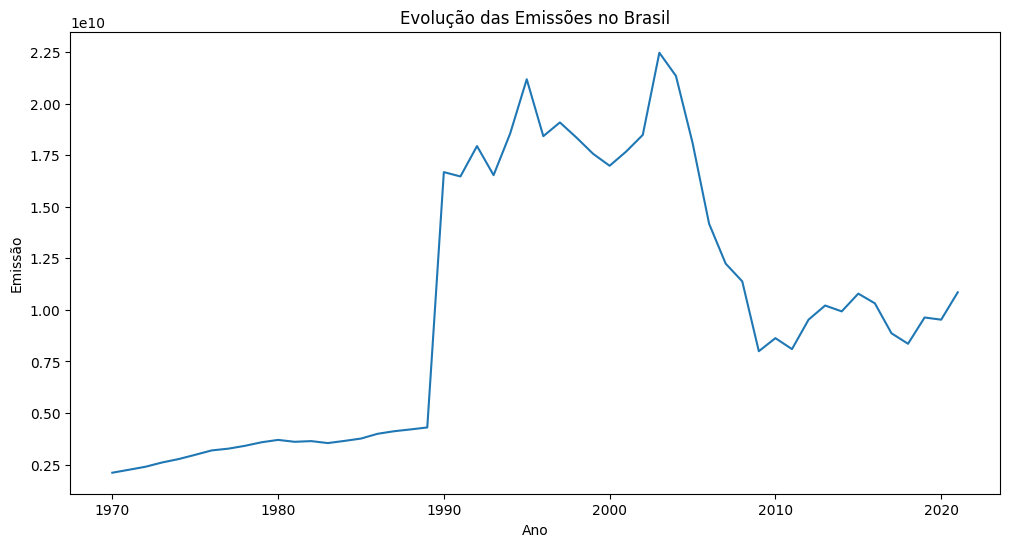

In [267]:
# A análise temporal permite observar tendências históricas nas emissões.
anos = list(range(1970, 2022))

emissao_temporal = emissoes_gases[anos].sum()
emissao_temporal.plot(figsize=(12,6))

plt.title('Evolução das Emissões no Brasil')
plt.xlabel('Ano')
plt.ylabel('Emissão')
plt.savefig('images/emissoes_temporal.png')
plt.show()

18. Transformação dos Dados com melt()

In [200]:
# O método melt() transforma o dataset de formato largo para formato longo. Isso facilita as análises, agrupamentos e visualizações
colunas_info = emissoes_gases.loc[:, 'Nível 1 - Setor':'Produto'].columns
colunas_emissoes = list(emissoes_gases.loc[:, 1970:2021].columns)
emissoes_por_ano = emissoes_gases.melt(id_vars=colunas_info, value_vars=colunas_emissoes, var_name='Ano', value_name='Emissão')
emissoes_por_ano.head()

,Nível 1 - Setor,Nível 2,Nível 3,Nível 4,Nível 5,Nível 6,Gás,Estado,Atividade Econômica,Produto,Ano,Emissão
0,Processos Industriais,Indústria Química,Produção de ABS,NaN,NaN,NaN,COVNM (t),SP,OUTRA_IND,NaN,1970,0.0
1,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,N2O (t),SP,OUTRA_IND,NaN,1970,6210.0
2,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO (t),SP,OUTRA_IND,NaN,1970,368.0
3,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,NOx (t),SP,OUTRA_IND,NaN,1970,115.0
4,Processos Industriais,Indústria Química,Produção de Ácido Adípico,NaN,NaN,NaN,CO2e (t) GWP-AR2,SP,OUTRA_IND,NaN,1970,1925100.0


19. Emissões Totais por Tipo de Gás

In [202]:
# A análise identifica quais gases possuem maior participação nas emissões brasileiras.
emissao_por_gas = (emissoes_por_ano.groupby('Gás')[['Emissão']].sum().sort_values('Emissão', ascending=False))

20. Visualização das Emissões por Tipo de Gás

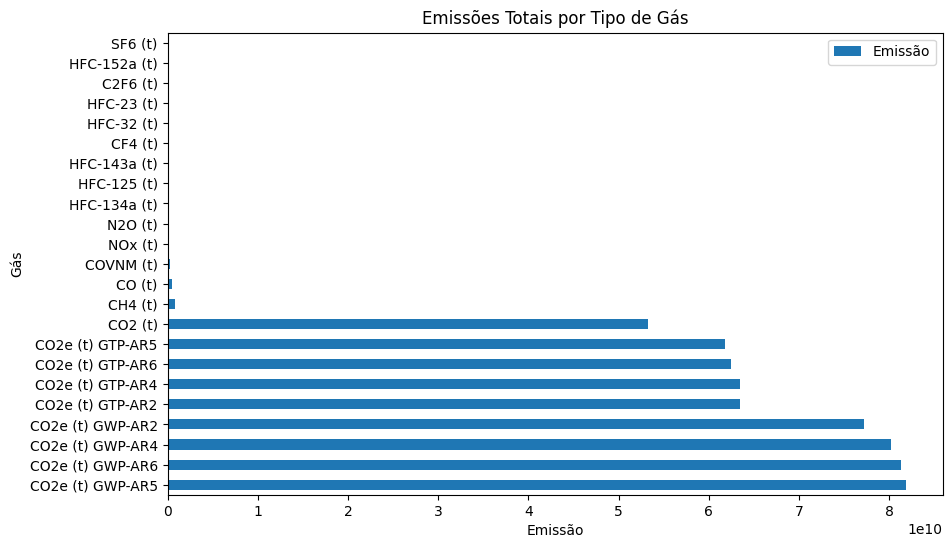

In [268]:
# O gráfico facilita a comparação entre os gases de efeito estufa.
emissao_por_gas.plot(kind='barh', figsize=(10,6))

plt.title('Emissões Totais por Tipo de Gás')
plt.xlabel('Emissão')
plt.ylabel('Gás')
plt.savefig('images/gas_estufa.png')
plt.show()

21. Participação do CO2 nas Emissões Totais

In [205]:
# Essa análise calcula a participação percentual do CO2 nas emissões totais.
print(
    f'A emissão de CO2 corresponde a '
    f'{float((emissao_por_gas.iloc[0:9].sum()/emissao_por_gas.sum()).iloc[0]) * 100:.2f}% '
    'das emissões totais de gases de efeito estufa no Brasil entre 1970 e 2021.'
)

A emissão de CO2 corresponde a 99.74% das emissões totais de gases de efeito estufa no Brasil entre 1970 e 2021.


22. Emissões por Setor Econômico

In [206]:
# A análise identifica quais setores econômicos mais contribuem para as emissões.
emissoes_por_ano.groupby('Nível 1 - Setor')[['Emissão']].sum().sort_values('Emissão', ascending=False)

,Emissão
Nível 1 - Setor,
Mudança de Uso da Terra e Floresta,3.524898e+11
Energia,1.205314e+11
Agropecuária,1.147284e+11
Processos Industriais,2.849965e+10
Resíduos,1.034465e+10


23. Relação entre Gases e Setores Econômicos

In [208]:
# O agrupamento por múltiplas colunas permite analisar a relação entre gases e atividades econômicas.
gas_por_setor = (emissoes_por_ano.groupby(['Gás', 'Nível 1 - Setor'])[['Emissão']].sum())

24. Setores Mais Poluentes para Cada Tipo de Gás

In [209]:
# A análise identifica qual setor econômico possui maior emissão para cada tipo de gás.
gas_por_setor.groupby(level=0).idxmax()

,Emissão
Gás,
C2F6 (t),"(C2F6 (t), Processos Industriais)"
CF4 (t),"(CF4 (t), Processos Industriais)"
CH4 (t),"(CH4 (t), Agropecuária)"
CO (t),"(CO (t), Energia)"
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)"
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F..."
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F..."


25. Quantidade Máxima de Emissão por Tipo de Gás

In [211]:
# A função max() retorna a maior quantidade de emissão associada a cada gás
gas_por_setor.groupby(level=0).max()

,Emissão
Gás,
C2F6 (t),5.765018e+02
CF4 (t),7.135481e+03
CH4 (t),5.928481e+08
CO (t),3.959769e+08
CO2 (t),3.733930e+10
CO2e (t) GTP-AR2,3.850044e+10
CO2e (t) GTP-AR4,3.850044e+10
CO2e (t) GTP-AR5,3.831675e+10
CO2e (t) GTP-AR6,3.843359e+10


26. Tabela Resumida dos Maiores Emissores

In [214]:
# A tabela resume:  o principal setor emissor de cada gás; a quantidade total emitida.
valores_max = gas_por_setor.groupby(level=0).max().values
tabela_sumarizada = gas_por_setor.groupby(level=0).idxmax()

tabela_sumarizada.insert(1, 'Quantidade de emissão', valores_max)
tabela_sumarizada

,Emissão,Quantidade de emissão
Gás,,
C2F6 (t),"(C2F6 (t), Processos Industriais)",5.765018e+02
CF4 (t),"(CF4 (t), Processos Industriais)",7.135481e+03
CH4 (t),"(CH4 (t), Agropecuária)",5.928481e+08
CO (t),"(CO (t), Energia)",3.959769e+08
CO2 (t),"(CO2 (t), Mudança de Uso da Terra e Floresta)",3.733930e+10
CO2e (t) GTP-AR2,"(CO2e (t) GTP-AR2, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR4,"(CO2e (t) GTP-AR4, Mudança de Uso da Terra e F...",3.850044e+10
CO2e (t) GTP-AR5,"(CO2e (t) GTP-AR5, Mudança de Uso da Terra e F...",3.831675e+10
CO2e (t) GTP-AR6,"(CO2e (t) GTP-AR6, Mudança de Uso da Terra e F...",3.843359e+10


27. Gases Mais Emitidos por Atividade Econômica

In [215]:
# O método swaplevel() troca os níveis do MultiIndex, permitindo analisar os gases dominantes em cada setor econômico.
gas_por_setor.swaplevel(0, 1).groupby(level=0).idxmax()

,Emissão
Nível 1 - Setor,
Agropecuária,"(Agropecuária, CO2e (t) GWP-AR5)"
Energia,"(Energia, CO2e (t) GWP-AR6)"
Mudança de Uso da Terra e Floresta,"(Mudança de Uso da Terra e Floresta, CO2e (t) ..."
Processos Industriais,"(Processos Industriais, CO2e (t) GWP-AR6)"
Resíduos,"(Resíduos , CO2e (t) GWP-AR5)"


28. Evolução Temporal das Emissões por Ano

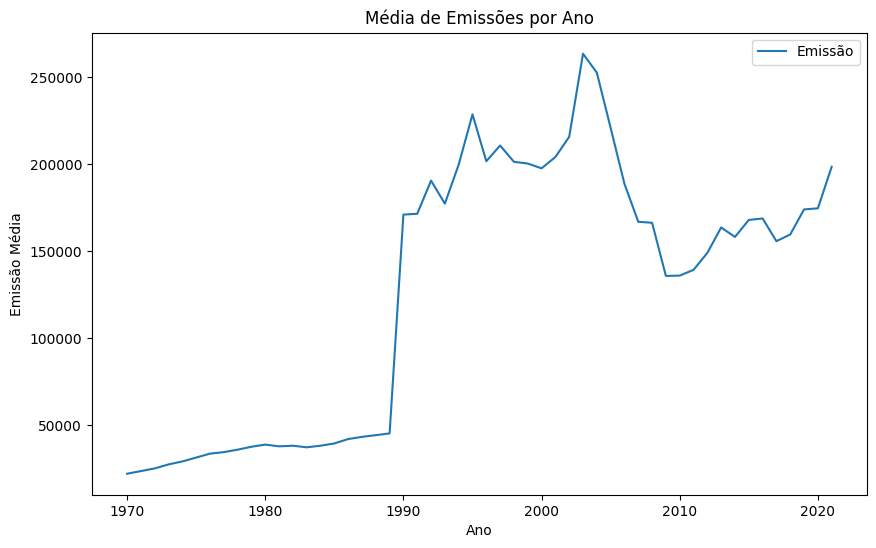

In [269]:
emissoes_por_ano.groupby('Ano')[['Emissão']].mean().plot(figsize=(10,6))

plt.title('Média de Emissões por Ano')
plt.xlabel('Ano')
plt.ylabel('Emissão Média')
plt.savefig('images/emissoes_anual.png')
plt.show()

29. Ano de Maior Emissão

In [218]:
# A análise identifica o ano com maior média de emissões.
emissoes_por_ano.groupby('Ano')[['Emissão']].mean().idxmax()

Emissão    2003
dtype: int64

30. Emissões Anuais por Tipo de Gás

In [220]:
# O agrupamento permite analisar a evolução temporal individual de cada gás.
media_emissao_anual = (emissoes_por_ano.groupby(['Ano', 'Gás'])[['Emissão']].mean().reset_index())
media_emissao_anual

,Ano,Gás,Emissão
0,1970,C2F6 (t),0.232610
1,1970,CF4 (t),3.557421
2,1970,CH4 (t),1471.024024
3,1970,CO (t),2155.556658
4,1970,CO2 (t),19244.913199
...,...,...,...
1191,2021,HFC-23 (t),0.000000
1192,2021,HFC-32 (t),261.100000
1193,2021,N2O (t),119.295311
1194,2021,NOx (t),679.395431


31. Pivot Table de Emissões por Gás

32. Visualização Temporal por Tipo de Gás

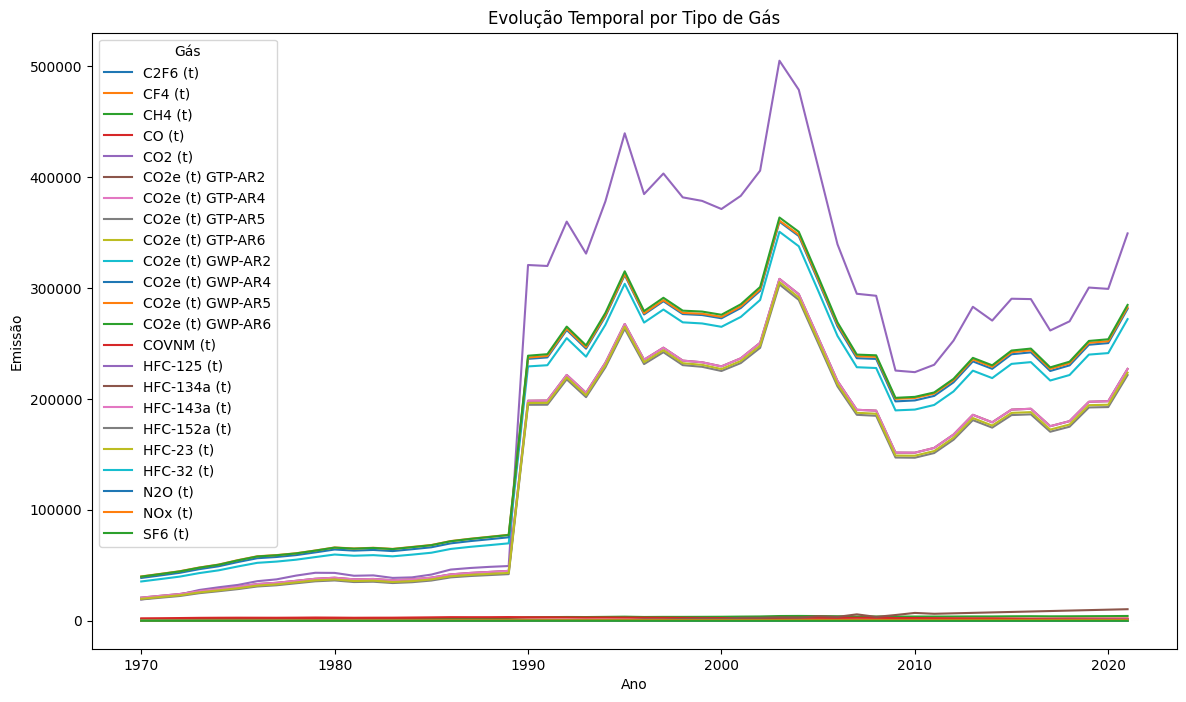

In [270]:
media_emissao_anual.plot(figsize=(14,8))

plt.title('Evolução Temporal por Tipo de Gás')
plt.xlabel('Ano')
plt.ylabel('Emissão')
plt.savefig('images/emissoes_media.png')
plt.show()

33. Emissões por Setor ao Longo do Tempo

In [231]:
# Essa análise permite comparar a evolução histórica dos setores econômicos.
emissao_setores = emissoes_por_ano.pivot_table(values='Emissão', index='Ano', columns='Nível 1 - Setor', aggfunc='mean')
emissao_setores

Nível 1 - Setor,Agropecuária,Energia,Mudança de Uso da Terra e Floresta,Processos Industriais,Resíduos
Ano,,,,,
1970,49292.425313,15939.703116,0.000000e+00,106549.168676,11684.883558
1971,51199.559433,17698.989894,0.000000e+00,111532.507753,12676.706849
1972,53508.935498,19092.876761,0.000000e+00,125701.525455,13709.697850
1973,55494.006224,22062.085929,0.000000e+00,137657.110402,14715.248028
1974,57896.513900,23810.659474,0.000000e+00,149941.779638,15710.616150
1975,63303.098508,25036.433686,0.000000e+00,168471.860169,16667.446706
1976,66347.533521,27214.281091,0.000000e+00,193826.482068,17539.505222
1977,66977.413505,27645.258640,0.000000e+00,231505.609283,18462.455148
1978,66640.432009,29734.461056,0.000000e+00,255736.210711,19327.840165


34. Visualização Temporal dos Setores Econômicos

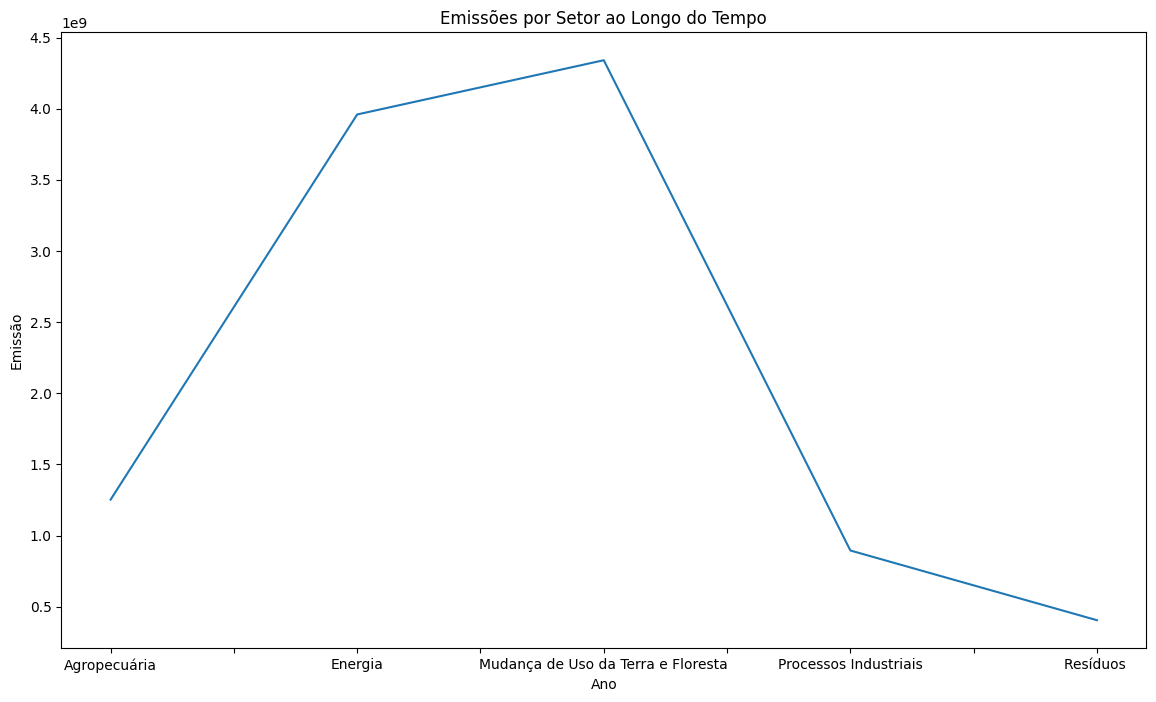

In [273]:
# O gráfico permite visualizar mudanças estruturais nas emissões dos setores econômicos.
emissao_setores.plot(figsize=(14,8))

plt.title('Emissões por Setor ao Longo do Tempo')
plt.xlabel('Ano')
plt.ylabel('Emissão')
plt.savefig('images/emissoes_setores.png')
plt.show()

35. Relação entre Estados e Setores Econômicos

In [236]:
# O agrupamento por estado e setor permite identificar padrões regionais das emissões.
emissoes_estados_setor = (emissoes_por_ano.groupby(['Estado', 'Nível 1 - Setor'])[['Emissão']].sum())
emissoes_estados_setor

Emissão
Estado Nível 1 - Setor                                 
AC     Agropecuária                        7.270206e+08
       Energia                             2.071751e+08
       Mudança de Uso da Terra e Floresta  7.847879e+09
       Resíduos                            2.928323e+07
AL     Agropecuária                        7.628303e+08
...                                                 ...
TO     Agropecuária                        2.762475e+09
       Energia                             5.130379e+08
       Mudança de Uso da Terra e Floresta  9.435591e+09
       Processos Industriais               2.613905e+07
       Resíduos                            6.177003e+07

[132 rows x 1 columns]

36. Análise de Setores por Estado

In [237]:
# O método xs() permite selecionar um subconjunto específico do MultiIndex.
emissoes_estados_setor.xs('Energia', level=1)

,Emissão
Estado,
AC,2.071751e+08
AL,5.958697e+08
AM,1.916462e+09
AP,2.638059e+08
BA,4.801368e+09
CE,1.879584e+09
DF,9.487860e+08
ES,2.201326e+09
GO,2.761709e+09


37. Setor com Maior Emissão em Cada Estado

In [238]:
# A análise identifica qual atividade econômica mais contribui para as emissões em cada estado.
emissoes_estados_setor.groupby(level=0).idxmax()

,Emissão
Estado,
AC,"(AC, Mudança de Uso da Terra e Floresta)"
AL,"(AL, Agropecuária)"
AM,"(AM, Mudança de Uso da Terra e Floresta)"
AP,"(AP, Mudança de Uso da Terra e Floresta)"
BA,"(BA, Mudança de Uso da Terra e Floresta)"
CE,"(CE, Energia)"
DF,"(DF, Energia)"
ES,"(ES, Processos Industriais)"
GO,"(GO, Agropecuária)"


38. Estado com Maior Emissão por Setor Econômico

In [240]:
# A análise identifica quais estados lideram as emissões em cada setor econômico
emissoes_estados_setor.groupby(level=1).idxmax()

,Emissão
Nível 1 - Setor,
Agropecuária,"(MG, Agropecuária)"
Energia,"(SP, Energia)"
Mudança de Uso da Terra e Floresta,"(PA, Mudança de Uso da Terra e Floresta)"
Processos Industriais,"(MG, Processos Industriais)"
Resíduos,"(SP, Resíduos )"


39. Principais Insights

Resultados observados
• O CO2 aparece como principal gás de efeito estufa emitido no Brasil

•Mudança de Uso da Terra e Floresta lidera as emissões entre o setores econômicos.

•O setor energético apresenta crescimento constante ao longo das décadas

•Alguns estados concentram grande parte das emissões nacionais

•A partir da década de 1990 observa-se crescimento expressivo das emissões totais

•O cruzamento entre gases e setores mostrou forte relação entre C02 e mudanças no uso da terra

40. Conclusão

  Este projeto permitiu investigar o comportamento histórico das emissões brasileiras de gases de efeito estufa utilizando técnicas de análise de dados com Python.
  Durante o desenvolvimento foram utilizadas ferramentas importantes como Pandas, e um monte de coisa

  •As análises mostram que as emissões cresceram signitificamente ao longo do tempo
  •O C02 domiina as emissões nacionais
  •Setores ligados ao uso da terra possuem grande impacto ambiental
  •existem diferenças regionais importantes entre os estados brasileiros
  